<a href="https://colab.research.google.com/github/curiosity-matrix/behavioral-personality-classifier/blob/main/Personality_Type_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
                                                                  # FILE UPLOAD

from google.colab import files
uploaded = files.upload()

Saving personality_synthetic_dataset.csv to personality_synthetic_dataset.csv


In [ ]:
                                                                  # LIBRARIES IMPORT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
                                                                # FILE READ
personality_Data = pd.read_csv('personality_synthetic_dataset.csv')

In [ ]:
personality_Data

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Ambivert,3.783857,4.345803,8.220063,6.297798,5.162622,5.702266,5.518356,3.420139,5.811565,...,8.521256,4.355973,6.454815,2.557365,6.949292,4.176390,5.649897,5.665498,5.252077,4.297520
19996,Introvert,2.621406,8.152097,2.954341,8.791467,2.670252,2.931244,5.855202,5.044124,6.244061,...,4.818308,2.631298,10.000000,3.697801,3.217559,3.638815,5.177155,5.106628,0.982214,5.873321
19997,Introvert,0.039689,8.277160,5.728101,7.790080,3.427897,0.708457,7.099321,5.784592,5.400400,...,3.318511,4.071008,9.974147,2.954407,5.427296,6.270830,3.793430,5.009167,3.810962,5.678412
19998,Extrovert,7.756725,3.956191,8.906972,3.793775,7.608467,6.292705,6.824980,5.653421,7.347820,...,7.156525,8.148780,3.840900,6.093418,7.814507,8.428745,8.736932,8.060841,8.161087,5.941793


In [ ]:
                                      # SHAPE CHECK

personality_Data.shape

(20000, 30)

In [ ]:
                                      # NULL VALUE CHECK

personality_Data.isnull().sum()

,0
personality_type,0
social_energy,0
alone_time_preference,0
talkativeness,0
deep_reflection,0
group_comfort,0
party_liking,0
listening_skill,0
empathy,0
creativity,0


In [ ]:
                                        # DUPLICATE CHECK

personality_Data.duplicated().sum()

np.int64(0)

In [ ]:
                                          # 0 VALUE CHECK

(personality_Data==0).sum()

,0
personality_type,0
social_energy,121
alone_time_preference,156
talkativeness,155
deep_reflection,18
group_comfort,33
party_liking,593
listening_skill,0
empathy,0
creativity,2


In [ ]:
                                # INFO CHECK ( data type, no nul counts )

personality_Data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [ ]:
                                                  # SKEW CHECK - to understand whether to fill mean or median
for col in personality_Data.columns :

  personality_Data[col]=personality_Data[col].replace(0,np.nan)

  if col == 'personality_type':

    continue

  skw = personality_Data[col].skew()


  if (skw > -1 and skw < 1):

    personality_Data[col] = personality_Data[col].fillna(personality_Data[col].mean())

  else :

    personality_Data[col] = personality_Data[col].fillna(personality_Data[col].median())

In [ ]:
                                                        # verifying 0 values in a dataset
(personality_Data==0).sum()

,0
personality_type,0
social_energy,0
alone_time_preference,0
talkativeness,0
deep_reflection,0
group_comfort,0
party_liking,0
listening_skill,0
empathy,0
creativity,0


In [ ]:
personality_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [ ]:
                                                          # CHECKING THE STATISTICS OF DATASET
personality_Data.describe()

,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,organization,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,5.542723,5.497571,5.569116,5.964056,6.024321,5.194067,6.964450,6.483220,5.996618,5.975072,...,5.499955,5.074822,5.948528,5.498813,6.499224,5.517211,6.007193,6.502961,5.525561,5.982281
std,2.430817,2.446381,2.439602,2.155018,2.164786,2.668901,1.647944,1.534911,1.495489,1.694432,...,1.916117,2.155875,2.160317,1.922716,1.888375,1.920245,1.682987,1.888103,1.930885,1.489726
min,0.001368,0.000102,0.003553,0.042981,0.013400,0.001683,1.308044,0.804853,0.754633,0.066264,...,0.002422,0.010053,0.034925,0.006021,0.168636,0.063628,0.022442,0.056492,0.006808,0.034922
25%,3.640515,3.571815,3.661029,4.390040,4.428815,3.005927,5.812701,5.448486,4.993084,4.807055,...,4.160591,3.494640,4.333478,4.135662,5.158811,4.166305,4.868130,5.161258,4.158214,4.973114
50%,5.542723,5.497571,5.574786,5.972345,6.051489,5.194067,6.989855,6.481365,6.003320,5.986871,...,5.499955,5.074822,5.962857,5.508153,6.528960,5.508014,6.007193,6.525735,5.528102,5.978713
75%,7.424123,7.416314,7.472371,7.598495,7.668598,7.363676,8.155574,7.521483,7.013412,7.142282,...,6.853083,6.656162,7.564929,6.861487,7.885414,6.877156,7.160525,7.878841,6.905844,6.991311
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
# DATA CLEANING DONE

In [ ]:
                                          # I/p(features) - o/p(target)

X = personality_Data.drop(columns=['personality_type'])
y = personality_Data['personality_type']

In [ ]:
X.shape

(20000, 29)

In [ ]:
y.shape

(20000,)

In [ ]:
                                          # DATA ENCODING ON y (O/p col)

from sklearn.preprocessing import LabelEncoder


In [ ]:
le = LabelEncoder()
y=le.fit_transform(y)                       # y will be in array

In [ ]:
print(le.classes_)

['Ambivert' 'Extrovert' 'Introvert']


In [ ]:
# DATA ENCODING DONE

In [ ]:
                                           # DATA SPLITTING

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
# Scaling not needed as my data is within range

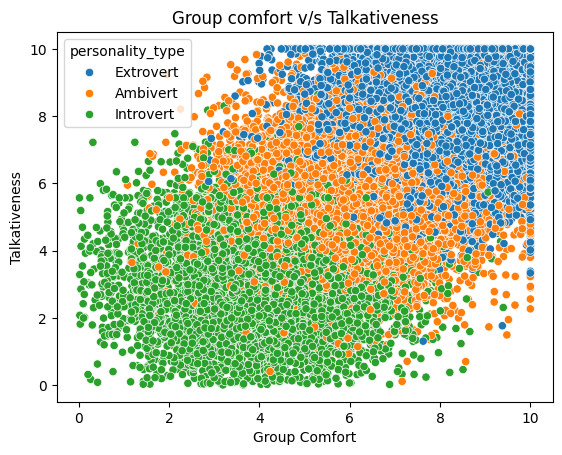

In [ ]:
import seaborn as sns

sns.scatterplot(data = personality_Data, x = 'group_comfort', y = 'talkativeness', hue = 'personality_type')

plt.xlabel('Group Comfort')
plt.ylabel('Talkativeness')
plt.title('Group comfort v/s Talkativeness')

plt.show()

([<matplotlib.patches.Wedge at 0x7f0276e1f920>,
 [Text(0.5212772744040172, 0.9686433828762364, 'Introvert'),
  Text(-1.0988823913376073, -0.04957307745280515, 'Extrovert'),
  Text(0.5644010382603559, -0.9441670763221055, 'Ambivert')],
 [Text(0.28433305876582754, 0.5283509361143107, '34.3'),
  Text(-0.5993903952750584, -0.027039860428802808, '32.9'),
  Text(0.30785511177837593, -0.5150002234484211, '32.8')])

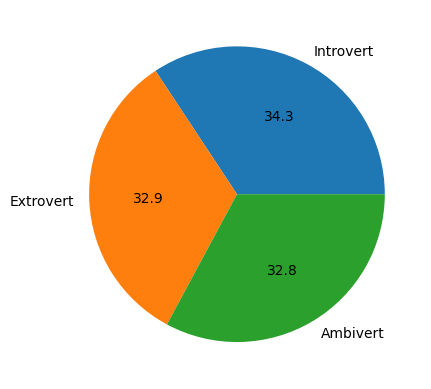

In [ ]:
plt.pie(personality_Data['personality_type'].value_counts(), labels = ['Introvert', 'Extrovert','Ambivert'], autopct = '%.1f')

In [ ]:
                                            # CREATE MODEL -  LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression


In [ ]:
log_reg_model = LogisticRegression()

In [ ]:
log_reg_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
log_reg_model_pred = log_reg_model.predict(X_test)

In [ ]:
                                            # evaluation

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
log_reg_acc_sc = accuracy_score(y_test,log_reg_model_pred)

log_reg_acc_sc      # -> 0.997

0.997

In [ ]:
                                                              # CREATE MODEL - KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [ ]:
acc_sc_list = []
for i in range(1,11):

  knn_model = KNeighborsClassifier(n_neighbors=i)

  knn_model.fit(X_train,y_train)

  knn_model_pred = knn_model.predict(X_test)

  knn_acc_sc = accuracy_score(y_test,knn_model_pred)

  acc_sc_list.append(knn_acc_sc)






In [ ]:
acc_sc_list

[0.994,
 0.9935,
 0.997,
 0.99625,
 0.99725,
 0.997,
 0.9975,
 0.99775,
 0.9975,
 0.9975]

In [ ]:
max_acc_sc = max(acc_sc_list)
print(max_acc_sc)

0.99775


In [ ]:
k_neighbor_val = acc_sc_list.index(max_acc_sc)+1
k_neighbor_val

8

In [ ]:
                  # hyperparameter tuning


knn_tuned_model = KNeighborsClassifier(n_neighbors=k_neighbor_val)

knn_tuned_model.fit(X_train,y_train)

knn_tuned_model_pred = knn_tuned_model.predict(X_test)

knn_tuned_acc_sc = accuracy_score(y_test,knn_tuned_model_pred)

knn_tuned_acc_sc              # -> 0.99775


0.99775

In [ ]:
                                        # MODEL CREATE - RANDOM FOREST CLASSIFIER

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
ran_for_classif_model = RandomForestClassifier()

In [ ]:
ran_for_classif_model.fit(X_train,y_train)

ran_for_classif_model_pred = ran_for_classif_model.predict(X_test)



In [ ]:
ran_for_classif_acc_sc = accuracy_score(y_test,ran_for_classif_model_pred)
ran_for_classif_acc_sc       # -> 0.99425

0.99525

In [ ]:
                                                      # MODEL CREATE - SVM

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
svm_linear_model = SVC(kernel='linear')
svm_linear_model.fit(X_train,y_train)
svm_linear_model_pred = svm_linear_model.predict(X_test)


In [ ]:
svm_linear_acc_sc = accuracy_score(y_test,svm_linear_model_pred)
svm_linear_acc_sc  # ->  0.997


0.997

In [ ]:
svm_poly_model = SVC(kernel='poly')

svm_poly_model.fit(X_train,y_train)

svm_poly_model_pred = svm_poly_model.predict(X_test)

svm_poly_acc_sc = accuracy_score(y_test,svm_poly_model_pred)

svm_poly_acc_sc      # -> 0.99725



0.99725

In [ ]:
svm_rbf_model = SVC(kernel='rbf')

svm_rbf_model.fit(X_train,y_train)

svm_rbf_model_pred = svm_rbf_model.predict(X_test)

svm_rbf_acc_sc = accuracy_score(y_test,svm_rbf_model_pred)

svm_rbf_acc_sc      # -> 0.99725



0.99725

In [ ]:
personality_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [ ]:
                                                                   # USER INPUT

features = ['social_energy','alone_time_preference','talkativeness','deep_reflection','group_comfort','party_liking','listening_skill','empathy','creativity','organization','leadership','risk_taking','public_speaking_comfort','curiosity','routine_preference','excitement_seeking','friendliness','emotional_stability','planning','spontaneity','adventurousness','reading_habit','sports_interest','online_social_usage','travel_desire','gadget_usage','work_style_collaborative','decision_speed','stress_handling']

In [ ]:
print("   🧠 PERSONALITY TYPE PREDICTOR  \n")

print("Rate yourself on each trait from 1 to 10\n")

print("*"*50 )

print("\n")

user_values = []

for feature in features:
    while True:
        try:
            val = float(input(f"  {feature.replace('_', ' ').title()} (1-10) : "))
            if 1 <= val <= 10:
                user_values.append(val)
                break
            else:
                print("   ⚠️  Please enter a value between 1 and 10")
        except ValueError:
            print("   ⚠️  Invalid input, enter a number")


user_df = pd.DataFrame([user_values], columns=features)
user_pred = knn_tuned_model.predict(user_df)

prediction_label = le.inverse_transform(user_pred)

print("\n")
print("*"*50)
print("\n")

print(f"Your personality type is  ->  {prediction_label[0]}")


   🧠 PERSONALITY TYPE PREDICTOR  

Rate yourself on each trait from 1 to 10

**************************************************


  Social Energy (1-10) : 3
  Alone Time Preference (1-10) : 4
  Talkativeness (1-10) : 7
  Deep Reflection (1-10) : 1
  Group Comfort (1-10) : 4
  Party Liking (1-10) : 6
  Listening Skill (1-10) : 8
  Empathy (1-10) : 9
  Creativity (1-10) : 0
   ⚠️  Please enter a value between 1 and 10
  Creativity (1-10) : 7
  Organization (1-10) : 6
  Leadership (1-10) : 7
  Risk Taking (1-10) : 5
  Public Speaking Comfort (1-10) : 4
  Curiosity (1-10) : 3
  Routine Preference (1-10) : 2
  Excitement Seeking (1-10) : 7
  Friendliness (1-10) : 8
  Emotional Stability (1-10) : 6
  Planning (1-10) : 5
  Spontaneity (1-10) : 4
  Adventurousness (1-10) : 3
  Reading Habit (1-10) : 5
  Sports Interest (1-10) : 6
  Online Social Usage (1-10) : 7
  Travel Desire (1-10) : 8
  Gadget Usage (1-10) : 1
  Work Style Collaborative (1-10) : 2
  Decision Speed (1-10) : 4
  Stress Handl

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn_tuned_model, X, y, cv=5)
print(scores.mean())

0.99685
